In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
sdss = pd.read_csv('Skyserver_SQL2_27_2018 6_51_39 PM.csv',skiprows=1)


In [3]:
sdss = sdss.drop(['objid','ra','dec','run','rerun','camcol','specobjid','fiberid'],axis=1)

In [4]:
sdss = sdss.drop((sdss[sdss['class']=='QSO']).index,axis=0)

In [5]:
sdss

,u,g,r,i,z,field,class,redshift,plate,mjd
0,19.47406,17.04240,15.94699,15.50342,15.22531,267,STAR,-0.000009,3306,54922
1,18.66280,17.21449,16.67637,16.48922,16.39150,267,STAR,-0.000055,323,51615
2,19.38298,18.19169,17.47428,17.08732,16.80125,268,GALAXY,0.123111,287,52023
3,17.76536,16.60272,16.16116,15.98233,15.90438,269,STAR,-0.000111,3306,54922
4,17.55025,16.26342,16.43869,16.55492,16.61326,269,STAR,0.000590,3306,54922
...,...,...,...,...,...,...,...,...,...,...
9995,18.81777,17.47053,16.91508,16.68305,16.50570,161,GALAXY,0.027583,447,51877
9996,18.27255,17.43849,17.07692,16.71661,16.69897,162,GALAXY,0.117772,447,51877
9997,18.75818,17.77784,17.51872,17.43302,17.42048,162,STAR,-0.000402,7303,57013
9998,18.88287,17.91068,17.53152,17.36284,17.13988,163,GALAXY,0.014019,447,51877


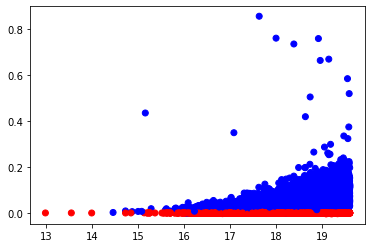

In [6]:
colors = {'STAR':'red', 'GALAXY':'blue'}
plt.scatter(sdss['u'],sdss['redshift'],c=sdss['class'].map(colors))


In [7]:
class Perceptron():

    def __init__ (self, labeled_data, iters, learning_rate, n):        
        # attributes now are: data, weights, iterations, learning rate
        self.data = labeled_data
        self.n = n
        self.weights = [1.0]*(self.n+1)
        self.iters = iters
        self.learning_rate = learning_rate
        
    def predict(self, feature_set):
        # predict a single result for one data point.
        # should be the dot product of features * weights + bias_weight
        dot_prod = np.dot(feature_set, self.weights[1:])+self.weights[0]
        # return 1 if the result is > 0 and -1 of it isn't
        if dot_prod>0:
            return 1
        else:
            return -1
    
    def fit(self):
        # for all iterations
        for i in range(self.iters):
        #    for each row in the data
            for j in range(len(self.data)):
                for k in range(self.n):
        #        find the update value, changes the weights (including bias weight)
                    self.weights[k+1]=self.weights[k+1]+self.learning_rate*(self.data[j][self.n]-self.predict(self.data[j][0:self.n]))*self.data[j][k]
                self.weights[0]=self.weights[0]+self.learning_rate*(self.data[j][self.n]-self.predict(self.data[j][0:self.n]))
        return self.weights
    def errors(self):
        # how many rows of the data don't match the provided label?
        x=0
        for i in range(len(self.data)):
            if self.predict(self.data[i][0:self.n])!=self.data[i][-1]:
                x+=1
            else:
                pass
        return x

In [8]:
cols = sdss.columns.tolist()
cols = ['u', 'g', 'r', 'i', 'z', 'field', 'redshift', 'plate', 'mjd','class']
sdss = sdss[cols]
sdss.to_csv('SDSS.csv')

In [9]:
sdss.head()

,u,g,r,i,z,field,redshift,plate,mjd,class
0,19.47406,17.04240,15.94699,15.50342,15.22531,267,-0.000009,3306,54922,STAR
1,18.66280,17.21449,16.67637,16.48922,16.39150,267,-0.000055,323,51615,STAR
2,19.38298,18.19169,17.47428,17.08732,16.80125,268,0.123111,287,52023,GALAXY
3,17.76536,16.60272,16.16116,15.98233,15.90438,269,-0.000111,3306,54922,STAR
4,17.55025,16.26342,16.43869,16.55492,16.61326,269,0.000590,3306,54922,STAR


In [10]:
f = open("SDSS.csv")
header = next(f) # dump the header line
data = []
for line in f:
    fields = line.split(",")
    # need to strip label because, as the last element, it has a \n
    label = (1.0 if fields[10].strip() == 'GALAXY' else -1.0)
    # the fields are strings until we conver them
    data1 = []
    for i in range(len(fields)-1):
        data1.append(float(fields[i]))
    data1.append(label)
    data.append(data1)
f.close()
data2 = []
for i in data:
    data2.append(i[1:])
p = Perceptron(data2, 100, 0.6, 9)
p.fit()
p.errors()
print('Accuracy=', 1-p.errors()/len(data))

Accuracy= 0.8379234972677596


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

In [12]:
sdss['label']=0
for i in range(len(sdss)):
    if sdss['class'].iloc[i]=='GALAXY':
        sdss['label'].iloc[i]=1
    else:
        sdss['label'].iloc[i]=-1
sdss

<ipython-input-12-f84b9da548a8>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sdss['label']=0
<ipython-input-12-f84b9da548a8>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sdss['label'].iloc[i]=-1
<ipython-input-12-f84b9da548a8>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sdss['label'].iloc[i]=1


,u,g,r,i,z,field,redshift,plate,mjd,class,label
0,19.47406,17.04240,15.94699,15.50342,15.22531,267,-0.000009,3306,54922,STAR,-1
1,18.66280,17.21449,16.67637,16.48922,16.39150,267,-0.000055,323,51615,STAR,-1
2,19.38298,18.19169,17.47428,17.08732,16.80125,268,0.123111,287,52023,GALAXY,1
3,17.76536,16.60272,16.16116,15.98233,15.90438,269,-0.000111,3306,54922,STAR,-1
4,17.55025,16.26342,16.43869,16.55492,16.61326,269,0.000590,3306,54922,STAR,-1
...,...,...,...,...,...,...,...,...,...,...,...
9995,18.81777,17.47053,16.91508,16.68305,16.50570,161,0.027583,447,51877,GALAXY,1
9996,18.27255,17.43849,17.07692,16.71661,16.69897,162,0.117772,447,51877,GALAXY,1
9997,18.75818,17.77784,17.51872,17.43302,17.42048,162,-0.000402,7303,57013,STAR,-1
9998,18.88287,17.91068,17.53152,17.36284,17.13988,163,0.014019,447,51877,GALAXY,1


In [13]:
X = sdss.iloc[:,:9]
y = sdss['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

In [14]:
X

,u,g,r,i,z,field,redshift,plate,mjd
0,19.47406,17.04240,15.94699,15.50342,15.22531,267,-0.000009,3306,54922
1,18.66280,17.21449,16.67637,16.48922,16.39150,267,-0.000055,323,51615
2,19.38298,18.19169,17.47428,17.08732,16.80125,268,0.123111,287,52023
3,17.76536,16.60272,16.16116,15.98233,15.90438,269,-0.000111,3306,54922
4,17.55025,16.26342,16.43869,16.55492,16.61326,269,0.000590,3306,54922
...,...,...,...,...,...,...,...,...,...
9995,18.81777,17.47053,16.91508,16.68305,16.50570,161,0.027583,447,51877
9996,18.27255,17.43849,17.07692,16.71661,16.69897,162,0.117772,447,51877
9997,18.75818,17.77784,17.51872,17.43302,17.42048,162,-0.000402,7303,57013
9998,18.88287,17.91068,17.53152,17.36284,17.13988,163,0.014019,447,51877


In [15]:
clf = MLPClassifier(verbose=True, learning_rate_init=0.01)

# Fit data onto the model
clf.fit(X_train,y_train)

Iteration 1, loss = 12.37756077
Iteration 2, loss = 7.01742416
Iteration 3, loss = 9.15855769
Iteration 4, loss = 7.17323633
Iteration 5, loss = 10.47242816
Iteration 6, loss = 6.55265083
Iteration 7, loss = 7.57412483
Iteration 8, loss = 7.22470418
Iteration 9, loss = 8.59490114
Iteration 10, loss = 7.32237403
Iteration 11, loss = 8.95775161
Iteration 12, loss = 8.31729911
Iteration 13, loss = 7.60125930
Iteration 14, loss = 7.33230509
Iteration 15, loss = 7.99793786
Iteration 16, loss = 7.83058877
Iteration 17, loss = 10.51659513
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.


MLPClassifier(learning_rate_init=0.01, verbose=True)

In [16]:
ypred=clf.predict(X_test)

# Import accuracy score 
from sklearn.metrics import accuracy_score

# Calcuate accuracy
accuracy_score(y_test,ypred)

0.8415300546448088

In [17]:
sdss = sdss.drop(['mjd','plate','field'],axis=1)

In [18]:
sdss.to_csv('SDSS.csv')

In [19]:
f = open("SDSS.csv")
header = next(f) # dump the header line
data = []
for line in f:
    fields = line.split(",")
    # need to strip label because, as the last element, it has a \n
    label = (1.0 if fields[7].strip() == 'GALAXY' else -1.0)
    # the fields are strings until we conver them
    data1 = []
    for i in range(len(fields)-2):
        data1.append(float(fields[i]))
    data1.append(label)
    data.append(data1)
f.close()
data2 = []
for i in data:
    data2.append(i[1:])
p = Perceptron(data2, 100, 0.6, 6)
p.fit()
p.errors()
print('Accuracy=', 1-p.errors()/len(data))

Accuracy= 0.885464480874317


In [20]:
X = sdss.iloc[:,:6]
y = sdss['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

# MLP Classifier:
- Multi-layer Perceptron classifier
- An MLP is characterized by several layers of input nodes connected as a directed graph between the input and output layers
- Since it is more beneficial to use when there are multiple useful features, we don't expect it to perform way better than our perceptron.

In [21]:
clf = MLPClassifier(verbose=True, learning_rate_init=0.01)

# Fit data onto the model
clf.fit(X_train,y_train)

Iteration 1, loss = 0.72173818
Iteration 2, loss = 0.59192494
Iteration 3, loss = 0.52638278
Iteration 4, loss = 0.47640833
Iteration 5, loss = 0.39718224
Iteration 6, loss = 0.35016509
Iteration 7, loss = 0.32024499
Iteration 8, loss = 0.27234494
Iteration 9, loss = 0.24689708
Iteration 10, loss = 0.20267000
Iteration 11, loss = 0.20897712
Iteration 12, loss = 0.19075370
Iteration 13, loss = 0.15639376
Iteration 14, loss = 0.15012059
Iteration 15, loss = 0.16124184
Iteration 16, loss = 0.14323580
Iteration 17, loss = 0.12544272
Iteration 18, loss = 0.10018671
Iteration 19, loss = 0.08875110
Iteration 20, loss = 0.28880048
Iteration 21, loss = 0.15308605
Iteration 22, loss = 0.12634628
Iteration 23, loss = 0.13054483
Iteration 24, loss = 0.12094082
Iteration 25, loss = 0.10863895
Iteration 26, loss = 0.11181232
Iteration 27, loss = 0.08782728
Iteration 28, loss = 0.08685181
Iteration 29, loss = 0.13347380
Iteration 30, loss = 0.08108465
Iteration 31, loss = 0.09468962
Iteration 32, los

MLPClassifier(learning_rate_init=0.01, verbose=True)

In [22]:
ypred=clf.predict(X_test)

# Calcuate accuracy
accuracy_score(y_test,ypred)

0.9901639344262295

In [23]:
sdss = sdss.drop(['u','g','r','i','z'],axis=1)

In [24]:
sdss.to_csv('SDSS.csv')

In [25]:
fields

['9999',
 '19.27586',
 '17.37829',
 '16.30542',
 '15.83548',
 '15.50588',
 '0.1184173',
 'GALAXY',
 '1\n']

In [26]:
f = open("SDSS.csv")
header = next(f) # dump the header line
data = []
for line in f:
    fields = line.split(",")
    # need to strip label because, as the last element, it has a \n
    label = (1.0 if fields[2].strip() == 'GALAXY' else -1.0)
    # the fields are strings until we conver them
    data1 = []
    for i in range(len(fields)-2):
        data1.append(float(fields[i]))
    data1.append(label)
    data.append(data1)
f.close()
data2 = []
for i in data:
    data2.append(i[1:])
p = Perceptron(data2, 100, 0.6, 1)
p.fit()
p.errors()
print('Accuracy=', 1-p.errors()/len(data))

Accuracy= 0.9953005464480874


In [27]:
X = sdss.iloc[:,:1]
y = sdss['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

In [28]:
clf = MLPClassifier(verbose=True, learning_rate_init=0.01)

# Fit data onto the model
clf.fit(X_train,y_train)

Iteration 1, loss = 0.64126206
Iteration 2, loss = 0.41616748
Iteration 3, loss = 0.21077476
Iteration 4, loss = 0.13209189
Iteration 5, loss = 0.09749828
Iteration 6, loss = 0.08060192
Iteration 7, loss = 0.06739441
Iteration 8, loss = 0.05912145
Iteration 9, loss = 0.05201077
Iteration 10, loss = 0.04859340
Iteration 11, loss = 0.04398634
Iteration 12, loss = 0.04269624
Iteration 13, loss = 0.03872933
Iteration 14, loss = 0.03698002
Iteration 15, loss = 0.03510323
Iteration 16, loss = 0.03478821
Iteration 17, loss = 0.03314727
Iteration 18, loss = 0.03265006
Iteration 19, loss = 0.03213680
Iteration 20, loss = 0.03081130
Iteration 21, loss = 0.02994964
Iteration 22, loss = 0.02869036
Iteration 23, loss = 0.02935107
Iteration 24, loss = 0.03018997
Iteration 25, loss = 0.02710811
Iteration 26, loss = 0.02648801
Iteration 27, loss = 0.02524426
Iteration 28, loss = 0.02869074
Iteration 29, loss = 0.02621976
Iteration 30, loss = 0.02464912
Iteration 31, loss = 0.02510908
Iteration 32, los

MLPClassifier(learning_rate_init=0.01, verbose=True)

In [29]:
ypred=clf.predict(X_test)

# Calcuate accuracy
accuracy_score(y_test,ypred)

0.9923497267759562

In [30]:
clf = MLPClassifier(verbose=True, learning_rate_init=0.01, activation = 'logistic')

# Fit data onto the model
clf.fit(X_train,y_train)
ypred=clf.predict(X_test)

# Calcuate accuracy
accuracy_score(y_test,ypred)

Iteration 1, loss = 0.68579076
Iteration 2, loss = 0.66390959
Iteration 3, loss = 0.61087321
Iteration 4, loss = 0.51687548
Iteration 5, loss = 0.40079125
Iteration 6, loss = 0.30168774
Iteration 7, loss = 0.23358792
Iteration 8, loss = 0.18873038
Iteration 9, loss = 0.15968989
Iteration 10, loss = 0.13796249
Iteration 11, loss = 0.12169024
Iteration 12, loss = 0.11075598
Iteration 13, loss = 0.10019878
Iteration 14, loss = 0.09200559
Iteration 15, loss = 0.08443692
Iteration 16, loss = 0.07985014
Iteration 17, loss = 0.07450932
Iteration 18, loss = 0.07058267
Iteration 19, loss = 0.06659724
Iteration 20, loss = 0.06399439
Iteration 21, loss = 0.06126519
Iteration 22, loss = 0.05835678
Iteration 23, loss = 0.05683941
Iteration 24, loss = 0.05438376
Iteration 25, loss = 0.05319855
Iteration 26, loss = 0.05041704
Iteration 27, loss = 0.04898536
Iteration 28, loss = 0.04756309
Iteration 29, loss = 0.04625284
Iteration 30, loss = 0.04557048
Iteration 31, loss = 0.04438033
Iteration 32, los

0.9923497267759562

In [31]:
clf = MLPClassifier(verbose=True, learning_rate_init=0.01, activation = 'tanh')

# Fit data onto the model
clf.fit(X_train,y_train)
ypred=clf.predict(X_test)

# Calcuate accuracy
accuracy_score(y_test,ypred)

Iteration 1, loss = 0.59302122
Iteration 2, loss = 0.30217500
Iteration 3, loss = 0.14361938
Iteration 4, loss = 0.09561659
Iteration 5, loss = 0.07343531
Iteration 6, loss = 0.06033642
Iteration 7, loss = 0.05353915
Iteration 8, loss = 0.04683629
Iteration 9, loss = 0.04312237
Iteration 10, loss = 0.04002944
Iteration 11, loss = 0.03761975
Iteration 12, loss = 0.03480360
Iteration 13, loss = 0.03411434
Iteration 14, loss = 0.03405448
Iteration 15, loss = 0.03086841
Iteration 16, loss = 0.03095126
Iteration 17, loss = 0.02899144
Iteration 18, loss = 0.02850689
Iteration 19, loss = 0.02988976
Iteration 20, loss = 0.02690731
Iteration 21, loss = 0.02820140
Iteration 22, loss = 0.02570774
Iteration 23, loss = 0.02709383
Iteration 24, loss = 0.02630825
Iteration 25, loss = 0.02518911
Iteration 26, loss = 0.02537976
Iteration 27, loss = 0.02451028
Iteration 28, loss = 0.02446208
Iteration 29, loss = 0.02561869
Iteration 30, loss = 0.02353423
Iteration 31, loss = 0.02334126
Iteration 32, los

0.9923497267759562

In [34]:
clf = MLPClassifier(verbose=True, learning_rate_init=1, activation = 'identity')

# Fit data onto the model
clf.fit(X_train,y_train)
ypred=clf.predict(X_test)

# Calcuate accuracy
accuracy_score(y_test,ypred)

Iteration 1, loss = 4.46917256
Iteration 2, loss = 0.57540945
Iteration 3, loss = 0.10345198
Iteration 4, loss = 0.02950873
Iteration 5, loss = 0.02744689
Iteration 6, loss = 0.02628697
Iteration 7, loss = 0.02610281
Iteration 8, loss = 0.02667150
Iteration 9, loss = 0.02542134
Iteration 10, loss = 0.02605834
Iteration 11, loss = 0.02528476
Iteration 12, loss = 0.02561331
Iteration 13, loss = 0.02566572
Iteration 14, loss = 0.02641206
Iteration 15, loss = 0.02798131
Iteration 16, loss = 0.02469038
Iteration 17, loss = 0.02581745
Iteration 18, loss = 0.03589016
Iteration 19, loss = 0.02487540
Iteration 20, loss = 0.02466549
Iteration 21, loss = 0.02431694
Iteration 22, loss = 0.02358408
Iteration 23, loss = 0.02423782
Iteration 24, loss = 0.02344930
Iteration 25, loss = 0.02388199
Iteration 26, loss = 0.02618044
Iteration 27, loss = 0.02541309
Iteration 28, loss = 0.02825988
Iteration 29, loss = 0.03303522
Iteration 30, loss = 0.02793786
Iteration 31, loss = 0.02421720
Iteration 32, los

0.9923497267759562

# SKLearn.Linear_Model.Perceptron:
- Built-in Perceptron Class in sklearn
- Linear perceptron classifier instead of using multiple layers.


In [35]:
from sklearn.linear_model import Perceptron

In [36]:
p = Perceptron(random_state=0)
p.fit(X_train,y_train)

predictions_train = p.predict(X_train)
predictions_test = p.predict(X_test)
train_score = accuracy_score(predictions_train, y_train)
print("score on train data: ", train_score)
test_score = accuracy_score(predictions_test, y_test)
print("score on test data: ", test_score)


score on train data:  0.985792349726776
score on test data:  0.9868852459016394


In [38]:
p = Perceptron(random_state=9, verbose = 1)
p.fit(X_train,y_train)

predictions_train = p.predict(X_train)
predictions_test = p.predict(X_test)
train_score = accuracy_score(predictions_train, y_train)
print("score on train data: ", train_score)
test_score = accuracy_score(predictions_test, y_test)
print("score on test data: ", test_score)


-- Epoch 1
Norm: 28.46, NNZs: 1, Bias: -1.000000, T: 8235, Avg. loss: 0.033272
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 35.32, NNZs: 1, Bias: -1.000000, T: 16470, Avg. loss: 0.013487
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 39.56, NNZs: 1, Bias: -1.000000, T: 24705, Avg. loss: 0.010350
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 42.65, NNZs: 1, Bias: -1.000000, T: 32940, Avg. loss: 0.009151
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 45.14, NNZs: 1, Bias: -1.000000, T: 41175, Avg. loss: 0.008189
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 47.26, NNZs: 1, Bias: -1.000000, T: 49410, Avg. loss: 0.007703
Total training time: 0.00 seconds.
-- Epoch 7
Norm: 48.88, NNZs: 1, Bias: -1.000000, T: 57645, Avg. loss: 0.007152
Total training time: 0.00 seconds.
-- Epoch 8
Norm: 50.32, NNZs: 1, Bias: -1.000000, T: 65880, Avg. loss: 0.007132
Total training time: 0.00 seconds.
-- Epoch 9
Norm: 51.63, NNZs: 1, Bias: -1.000000, T: 74115, Avg. loss: 0.006594
T